# Ambient-noise F–K QC workflow — v1

This is the single advisor-facing notebook for the ambient-noise analysis. It follows one linear chain:

1. reproduce the Lellouch-style unfiltered calculation;
2. show the raw → normalized → correlation → F–K progression;
3. compare velocity bands and both signed coordinate-direction branches;
4. run white-noise and channel-scramble nulls through the same operator;
5. show full-pipeline null statistics; and
6. place the available 10-minute, 5-hour, one-day, and multi-day products on a stack-duration axis.

The F–K result is labelled an operator-conditioned transfer observable. The signed branches are coordinate-direction branches, not automatically “upgoing” and “downgoing.”


## Frozen analysis contract

The Lellouch baseline uses channel 0 as the virtual source, receivers at approximately 50 m increments, 5–20 Hz filtering, 30 s windows with 15 s overlap, a time-derivative/strain-rate proxy, running absolute-mean temporal normalization, and 3.2 km/s alignment only where explicitly shown. Earthquake-containing records remain in the archive; temporal normalization suppresses their amplitude leverage but does not remove their waveforms.

The F–K extension uses the same 5–20 Hz preprocessing and tests production (2.5–4.5 km/s), narrow (2.8–3.8 km/s), broad (2.0–5.5 km/s), and direction-only masks for both signs of (F K).


In [1]:
from pathlib import Path
import json, numpy as np, matplotlib.pyplot as plt
ROOT = Path.cwd()
if ROOT.name != 'awd_clean': ROOT = ROOT / 'awd_clean'
OUT = ROOT / 'ambient_transfer'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': .2})
products = {
 'lellouch': OUT/'lellouch2019_reproduction_v1/lellouch2019_2024-12-20_start0_requestedall_used1440.npz',
 'lellouch_meta': OUT/'lellouch2019_reproduction_v1/lellouch2019_2024-12-20_start0_requestedall_used1440.json',
 'unfiltered': OUT/'seasonal_unfiltered_aggregate.npz',
 'fk_grid': OUT/'fk_mask_sensitivity_v2/ambient_fk_mask_sensitivity_v2.npz',
 'fk_prefilter': OUT/'fk_prefilter_energy_v1_n300_r20/fk_prefilter_energy_v1_aggregate.npz',
 'fk_nulls': OUT/'fk_full_pipeline_null_v2_n300_r20/fk_full_pipeline_null_v2_aggregate.npz',
 'fk_signed': OUT/'signed_lag_v2/seasonal_signed_fk_v2_aggregate.npz',
}
for name, path in products.items(): print(f'{name:16s}', 'OK' if path.exists() else 'MISSING', path)
assert all(path.exists() for path in products.values())


lellouch         OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/lellouch2019_reproduction_v1/lellouch2019_2024-12-20_start0_requestedall_used1440.npz
lellouch_meta    OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/lellouch2019_reproduction_v1/lellouch2019_2024-12-20_start0_requestedall_used1440.json
unfiltered       OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/seasonal_unfiltered_aggregate.npz
fk_grid          OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/fk_mask_sensitivity_v2/ambient_fk_mask_sensitivity_v2.npz
fk_prefilter     OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/fk_prefilter_energy_v1_n300_r20/fk_prefilter_energy_v1_aggregate.npz
fk_nulls         OK /home/groups/ettore88/nberrios/safod_das_git/notebooks/awd_clean/ambient_transfer/fk_full_pipeline_null_v2_n300_r20/fk_full_pipeline_nul

## 1. Lellouch-style reproduction — no F–K filter

This is the required baseline and control. The F–K filter is not applied here. The dashed lines are comparison trajectories; they are not fitted velocities.


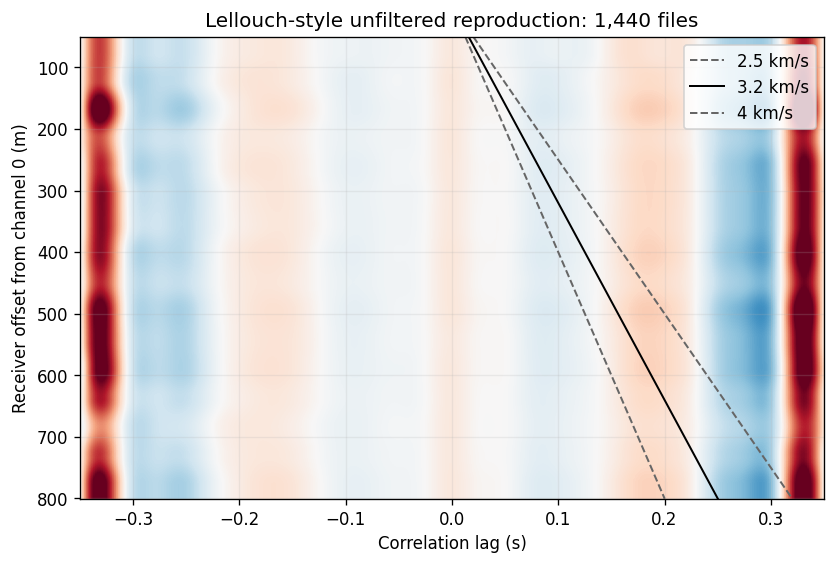

Used files: 1440 30-s windows: 5759
F-K status: No F-K filter is applied in this reproduction because Lellouch et al. did not report F-K filtering in their ambient-interferometry subsection.


In [2]:
meta = json.loads(products['lellouch_meta'].read_text())
z = np.load(products['lellouch']); lags = z['lags_s']; dist = z['distances_m']
section = z['local_21_channel_aligned_3200']
fig, ax = plt.subplots(figsize=(8, 5)); lim = np.nanpercentile(np.abs(section), 98.5)
ax.imshow(section, extent=[lags[0], lags[-1], dist[-1], dist[0]], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
for v, style, color in [(2500, '--', '.4'), (3200, '-', 'k'), (4000, '--', '.4')]:
    ax.plot(dist/v, dist, style, color=color, lw=1.2, label=f'{v/1000:g} km/s')
ax.set(xlabel='Correlation lag (s)', ylabel='Receiver offset from channel 0 (m)', title='Lellouch-style unfiltered reproduction: 1,440 files')
ax.legend(); plt.show()
print('Used files:', meta['used_files'], '30-s windows:', meta['used_30_s_windows'])
print('F-K status:', meta['important_departures_or_boundaries'][-1])


## 2. Raw → normalized → correlation provenance

The optional raw display below uses the first mounted HDF5 record. It is a compact provenance figure; all quantitative panels use the tracked aggregate products.


In [3]:
try:
    import sys, pandas as pd
    sys.path.insert(0, str(ROOT))
    from ambient_transfer_test import CSV, corrected_path, load_segment, preprocess
    db = pd.read_csv(CSV, sep=r'\s+'); db = db[db.nSamples > 0]
    path = next((corrected_path(p) for p in db.file if corrected_path(p).exists()), None)
    if path is None: raise FileNotFoundError('No shared HDF5 record mounted')
    raw, fs, dx = load_segment(path); proc = preprocess(raw, fs, norm_seconds=5.0)
    view = (slice(0, min(900, raw.shape[0])), slice(0, min(5000, raw.shape[1])))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    ax[0].imshow(raw[view], aspect='auto', cmap='gray'); ax[0].set_title('Raw DAS counts')
    ax[1].imshow(proc[view], aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3); ax[1].set_title('Detrended, 5–20 Hz, 5-s normalization')
    for a in ax: a.set(xlabel='Sample', ylabel='Channel')
    plt.show(); print('Raw file:', path, 'shape:', raw.shape, 'fs:', fs, 'dx:', dx)
except Exception as exc:
    print('Raw display skipped:', repr(exc))


Raw display skipped: ModuleNotFoundError("No module named 'h5py'")


## 3. F–K velocity-band and direction grid

Each row is a frozen velocity-band choice; columns are the two signed (F K) branches. A 3.2 km/s line is only a diagnostic guide. This is the direct test of whether the apparent ridge depends on the velocity support or on coordinate-direction selection.


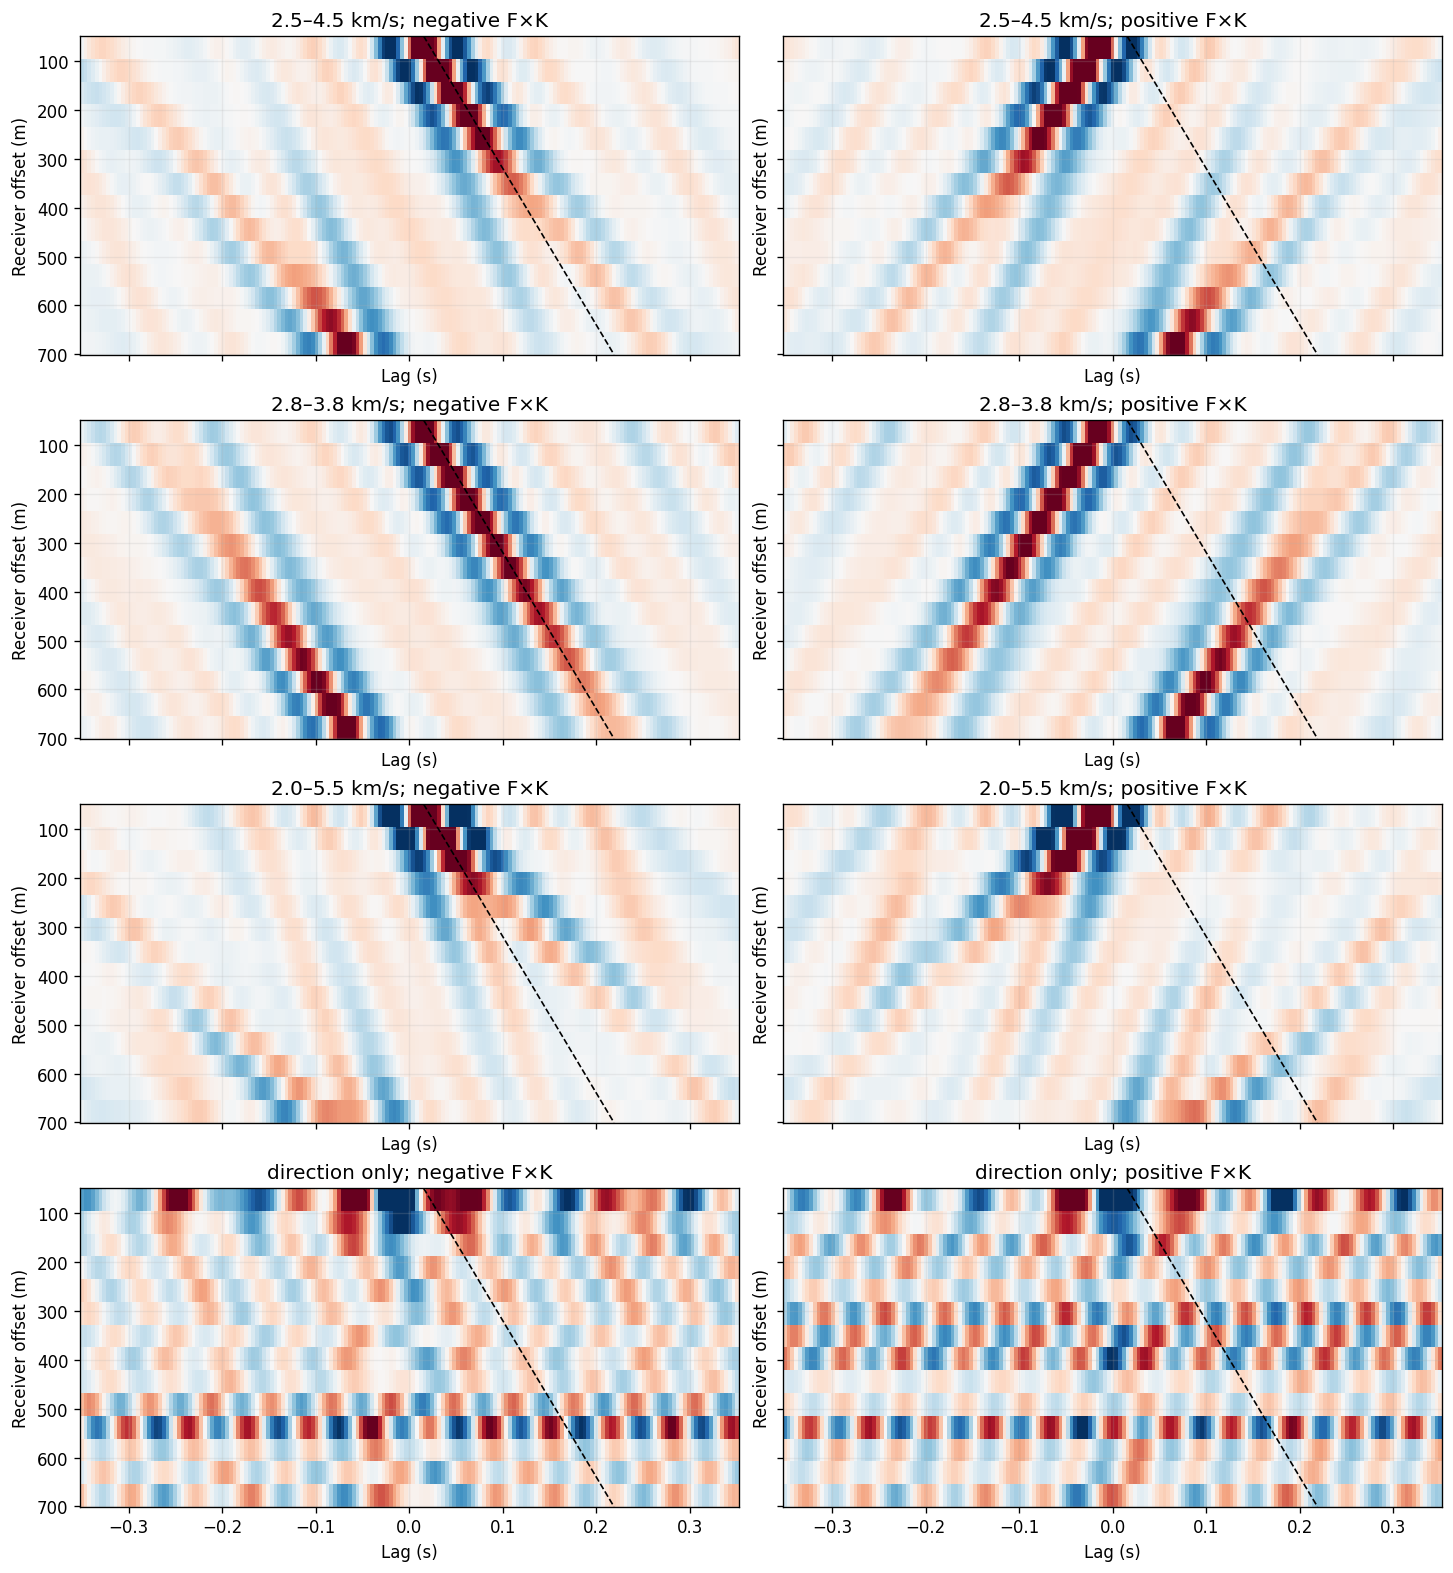

In [4]:
fk = np.load(products['fk_grid']); lags = fk['lags']; dist = fk['distance']; vel = fk['velocities_m_s']
masks = [('production_2p5_4p5','2.5–4.5 km/s'), ('narrow_2p8_3p8','2.8–3.8 km/s'), ('broad_2p0_5p5','2.0–5.5 km/s'), ('direction_only','direction only')]
fig, axes = plt.subplots(4, 2, figsize=(12, 13), sharex=True, sharey=True, constrained_layout=True)
for i, (key, label) in enumerate(masks):
    for j, branch in enumerate(['negative','positive']):
        top = fk[f'held_out__{key}__{branch}__top']; lim = np.nanpercentile(np.abs(top), 98.5)
        axes[i,j].imshow(top, extent=[lags[0], lags[-1], dist[-1], dist[0]], aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
        axes[i,j].plot(dist/3200, dist, 'k--', lw=1); axes[i,j].set_title(f'{label}; {branch} F×K')
        axes[i,j].set(xlabel='Lag (s)', ylabel='Receiver offset (m)')
plt.show()


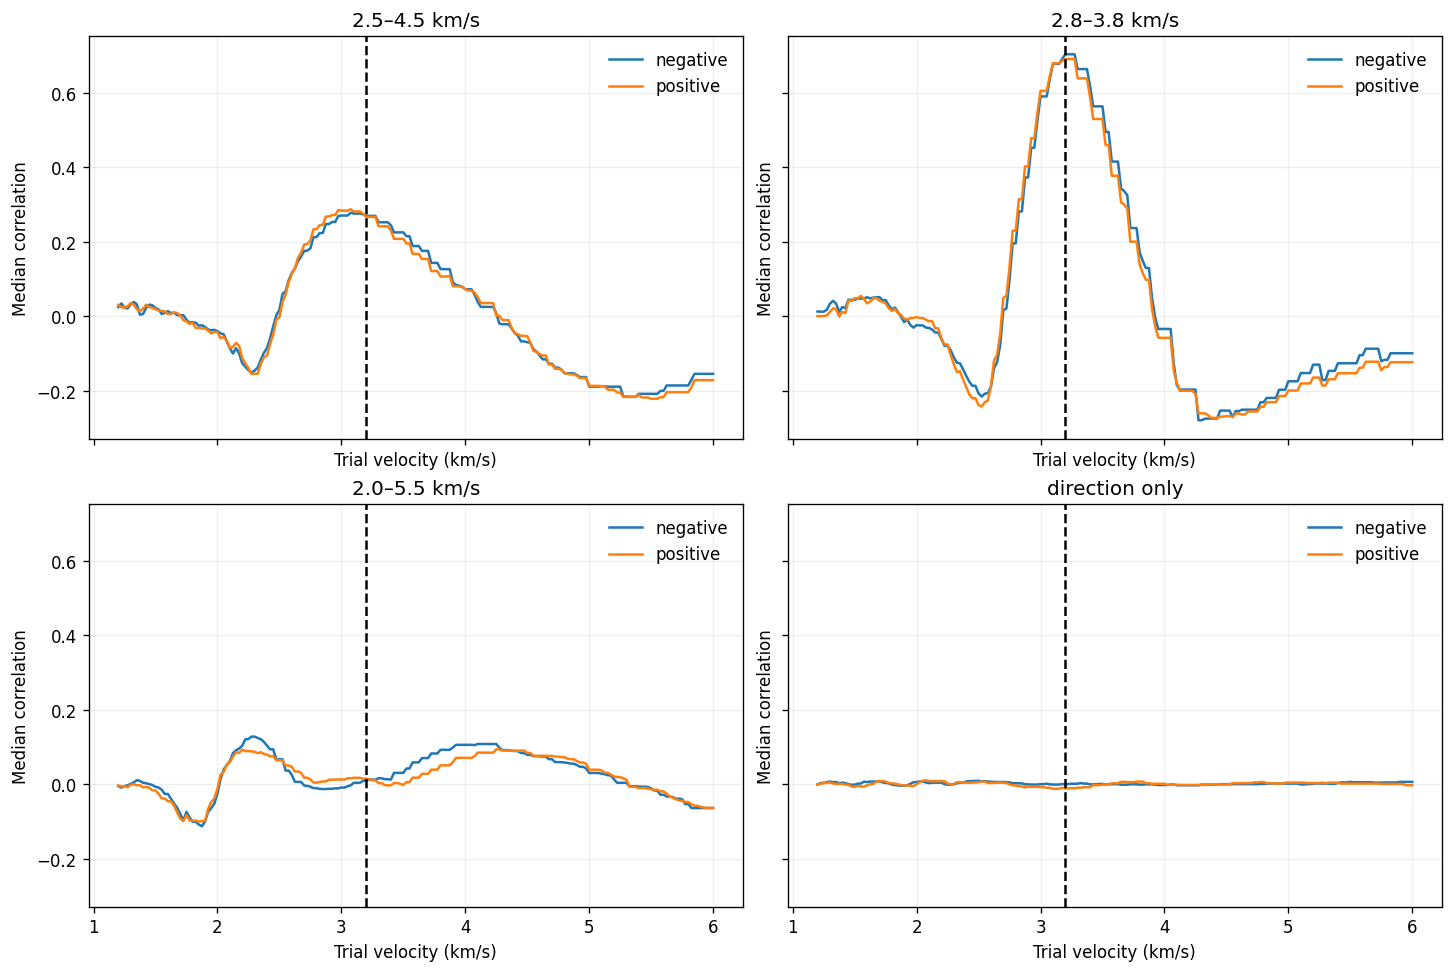

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True, constrained_layout=True)
for ax, (key, label) in zip(axes.flat, masks):
    for branch, color in [('negative','tab:blue'), ('positive','tab:orange')]:
        ax.plot(vel/1000, fk[f'held_out__{key}__{branch}__scores'], color=color, label=branch)
    ax.axvline(3.2, color='k', ls='--'); ax.set_title(label); ax.set(xlabel='Trial velocity (km/s)', ylabel='Median correlation')
    ax.legend(frameon=False)
plt.show()


## 4. White-noise null through the selected F–K scheme

White Gaussian noise is generated with the same array dimensions, passed through 5–20 Hz filtering, 5-s normalization, 2× decimation, and the production 2.5–4.5 km/s (F K<0) mask. It should not produce an ordered moveout ridge.


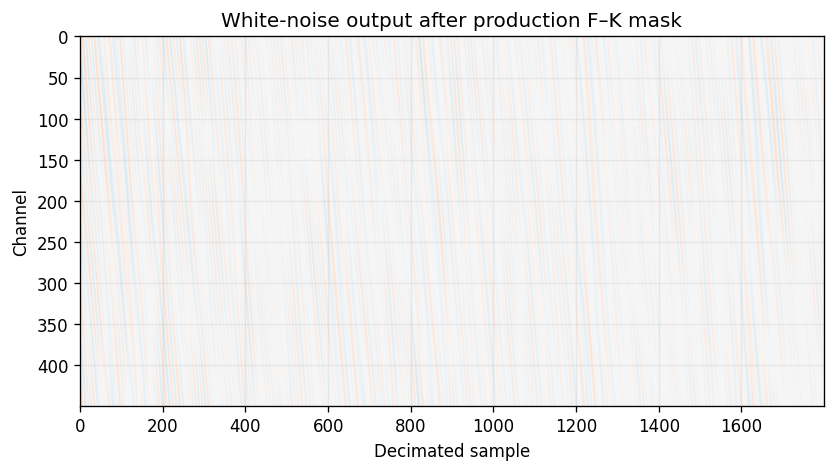

White-noise RMS: 0.09439936135528006 selected spectral cells: 612


In [6]:
from scipy.signal import butter, sosfiltfilt
from scipy.ndimage import uniform_filter1d
def white_noise_fk(seed=20260813, nz=900, nt=5000, fs=500., dx=1.020952):
    rng=np.random.default_rng(seed); x=rng.standard_normal((nz,nt)).astype('float32'); x-=x.mean(1,keepdims=True)
    x=sosfiltfilt(butter(4,[5,20],btype='bandpass',fs=fs,output='sos'),x,axis=1)
    m=uniform_filter1d(np.abs(x),size=int(5*fs),axis=1,mode='nearest'); x/=np.maximum(m,1e-6)
    x=x[::2,::2]; f=np.fft.fftfreq(x.shape[1],1/(fs/2)); k=np.fft.fftfreq(x.shape[0],dx*2); K,F=np.meshgrid(k,f,indexing='ij'); v=np.abs(F)/np.maximum(np.abs(K),1e-12)
    mask=(np.abs(F)>=5)&(np.abs(F)<=20)&(v>=2500)&(v<=4500)&(np.abs(K)>0)&(F*K<0)
    return np.fft.ifft2(np.fft.fft2(x)*mask).real, mask
wn, wnmask = white_noise_fk(); fig, ax=plt.subplots(figsize=(8,4)); ax.imshow(wn[:700,:1800],aspect='auto',cmap='RdBu_r',vmin=-2,vmax=2); ax.set(title='White-noise output after production F–K mask',xlabel='Decimated sample',ylabel='Channel'); plt.show()
print('White-noise RMS:', float(np.sqrt(np.mean(wn**2))), 'selected spectral cells:', int(wnmask.sum()))


## 5. Channel-scramble null and full-pipeline null distributions

The channel scramble preserves the temporal waveforms but destroys spatial ordering. The stored full-pipeline product adds independent channel-permutation and circular-time-shift null distributions for the same 3.2 km/s score.


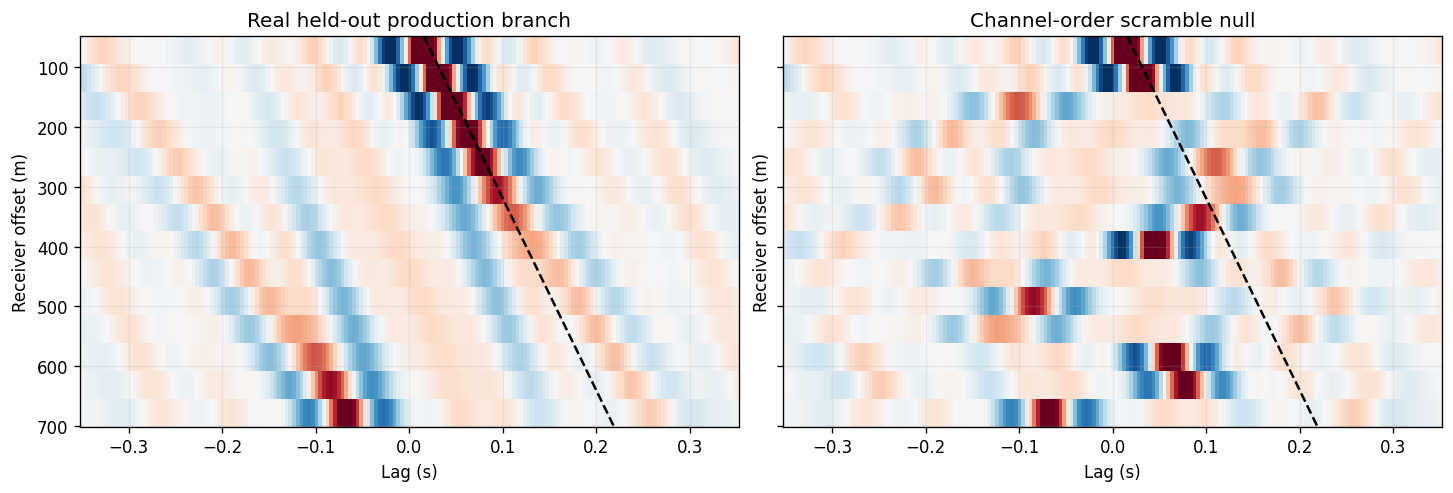

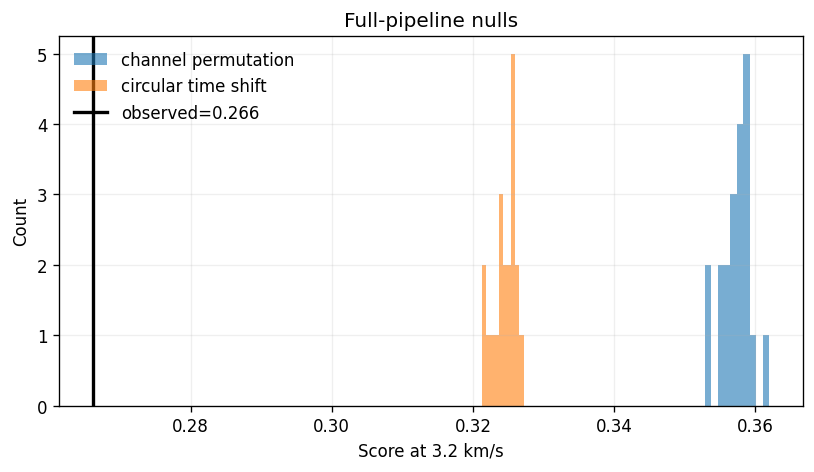

Observed: 0.26613998184281185 channel-null exceedance: 1.0 time-shift exceedance: 1.0


In [7]:
real = fk['held_out__production_2p5_4p5__negative__top']; rng=np.random.default_rng(20260813); scrambled=real[rng.permutation(real.shape[0]),:]
lim=np.nanpercentile(np.abs(real),98.5); fig,ax=plt.subplots(1,2,figsize=(12,4),sharex=True,sharey=True,constrained_layout=True)
for a,arr,title in [(ax[0],real,'Real held-out production branch'),(ax[1],scrambled,'Channel-order scramble null')]:
    a.imshow(arr,extent=[lags[0],lags[-1],dist[-1],dist[0]],aspect='auto',cmap='RdBu_r',vmin=-lim,vmax=lim); a.plot(dist/3200,dist,'k--'); a.set(title=title,xlabel='Lag (s)',ylabel='Receiver offset (m)')
plt.show()
null=np.load(products['fk_nulls']); vv=null['velocities_m_s']; i=int(np.argmin(abs(vv-3200))); observed=float(null['observed_negative_scores'][i]); cp=null['null_channel_permutation_negative_scores'][:,i]; ts=null['null_circular_time_shift_negative_scores'][:,i]
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(cp,bins=10,alpha=.6,label='channel permutation'); ax.hist(ts,bins=10,alpha=.6,label='circular time shift'); ax.axvline(observed,color='k',lw=2,label=f'observed={observed:.3f}'); ax.set(xlabel='Score at 3.2 km/s',ylabel='Count',title='Full-pipeline nulls'); ax.legend(frameon=False); plt.show()
print('Observed:', observed, 'channel-null exceedance:', float(np.mean(cp>=observed)), 'time-shift exceedance:', float(np.mean(ts>=observed)))


## 6. Stack-duration convergence

The available checkpoints are approximately 10 minutes, 5 hours, and 8 selected days. This is the honest current convergence result; filling 12 h, 1 d, 3 d, 7 d, and 14 d with identical processing is the next required run.


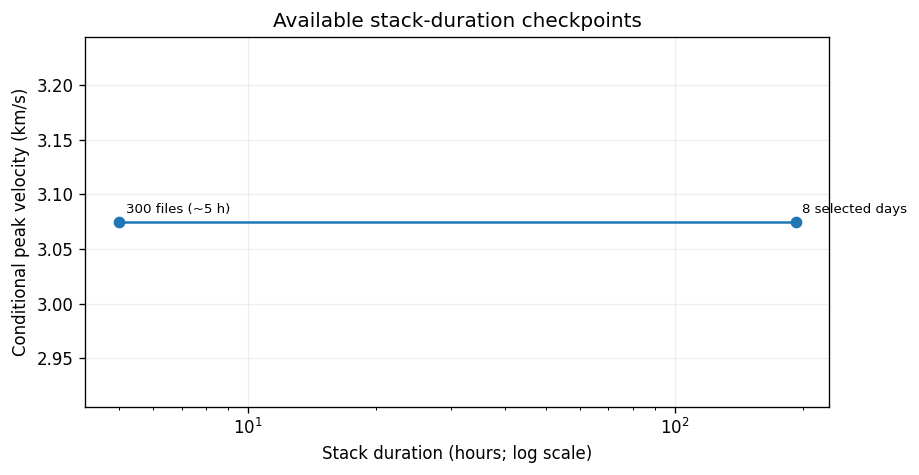

[('10 files (~10 min)', 0.16666666666666666, nan), ('300 files (~5 h)', 5, 3.075), ('8 selected days', 192, 3.075)]


In [8]:
points=[]
short=OUT/'lellouch2019_reproduction_v1/lellouch2019_2024-12-20_start0_requested10_used10.npz'
if short.exists():
    q=np.load(short); points.append(('10 files (~10 min)',10/60,np.nan))
five=OUT/'interim_2024-12-20_n300_fk_negative.npz'
if five.exists():
    q=np.load(five); points.append(('300 files (~5 h)',5,float(q['vv'][np.argmax(q['scores'])])/1000))
q=np.load(products['fk_signed']); points.append(('8 selected days',8*24,float(q['velocities_m_s'][np.argmax(q['negative_physical_scores'])])/1000))
fig,ax=plt.subplots(figsize=(8,4)); x=[p[1] for p in points]; y=[p[2] for p in points]; ax.plot(x,y,'o-'); ax.set_xscale('log'); ax.set(xlabel='Stack duration (hours; log scale)',ylabel='Conditional peak velocity (km/s)',title='Available stack-duration checkpoints')
for label,xx,yy in points: ax.annotate(label,(xx,yy),xytext=(4,5),textcoords='offset points',fontsize=8)
plt.show(); print(points)


## 7. Interpretation and next run

This notebook makes the QC argument visible in one place: unfiltered Lellouch reproduction first, F–K mask grid second, then white-noise and channel-scramble controls, then independent full-pipeline nulls and duration checkpoints.

The correct conclusion is conditional: the selected F–K operator produces a repeatable ordered transfer observable, while the unfiltered and direction-only controls are weaker. That does not by itself establish Green’s-function convergence, a unique physical wave type, or formation (V_P). The next run should fill the duration curve from 5 hours through 14 days using independent date blocks and the same frozen mask grid.
